In [1]:
import time
import os

In [15]:
import time
import os

import ase.build
from mace.calculators import mace_anicc, mace_off
from ase.io import write, read
import nqetools as nqe
from ase.visualize import view
import matplotlib.pyplot as plt
import ipi
import chemiscope
# This follows:
# https://atomistic-cookbook.org/examples/path-integrals/path-integrals.html




In [10]:
# Make a directory to store everything
directory = "PIMD"
n_beads = 8

In [5]:
# build the molecule
atoms = read("water_32.pdb")
atoms.center(vacuum=0.0)
# Set PBC
atoms.set_pbc([True, True, True])


In [9]:
# Make sure the directory is empty
nqe.remove_directory(directory)
# Run the calculation
nqe.run_md(directory, atoms, driver='ase-mace', md_type="NVT", xml_in="input_pimd.xml", n_beads=n_beads, timestep=0.5, total_steps=200, stride=1,temperature=298)

Running the MD (NVT) with the driver: python3 run-ase-mace.py


/home/louie/anaconda3/envs/ipi_env2/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = torch.lo

Using MACE-OFF23 MODEL for MACECalculator with /home/louie/.cache/mace/MACE-OFF23_small.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.

 ____       ____       ____       ____
/    \     /    \     /    \     /    \
|  #################################  |
\__#_/     \____/     \____/     \_#__/
   #    _        _______  _____    #
   #   (_)      |_   __ \|_   _|   #      -*-   v 3.1  -*-
   #   __  ______ | |__) | | |     #
   Y  [  ||______||  ___/  | |     #      A Universal Force Engine
  0 0  | |       _| |_    _| |_    #
   #  [___]     |_____|  |_____|   #
 __#_       ____       ____       _#__
/  # \     /    \     /    \     / #  \
|  #################################  |
\____/     \____/     \____/     \____/

    
 @system: Initializing system object 
 @simulation: Initializing simulation object 
@ RANDO

[Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, cell=[[50.418999183932286, 0.0, 0.0], [3.1227880181548176e-15, 50.99899857377693, 0.0], [3.0925393947096914e-15, 3.0925393947096914e-15, 50.5050010641899]]),
 Atoms(symbols='H64O32', pbc=True, 

In [11]:
# Read the results
# drops first frame where all atoms overlap
output_data, output_desc = ipi.read_output(os.path.join(directory,"md.out"))
traj_data = [ipi.read_trajectory(os.path.join(directory,f"md.pos_{i}.xyz"))[1:] for i in range(n_beads)]

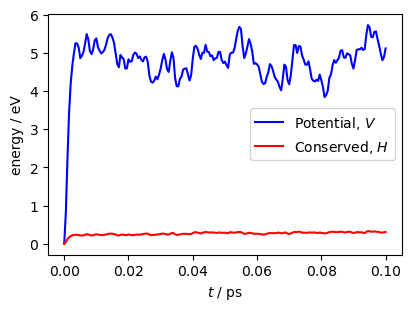

In [12]:
fix, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
ax.plot(
    output_data["time"],
    output_data["potential"] - output_data["potential"][0],
    "b-",
    label="Potential, $V$",
)
ax.plot(
    output_data["time"],
    output_data["conserved"] - output_data["conserved"][0],
    "r-",
    label="Conserved, $H$",
)
ax.set_xlabel(r"$t$ / ps")
ax.set_ylabel(r"energy / eV")
ax.legend()
plt.show()
# https://github.com/lab-cosmo/chemiscope/issues/390

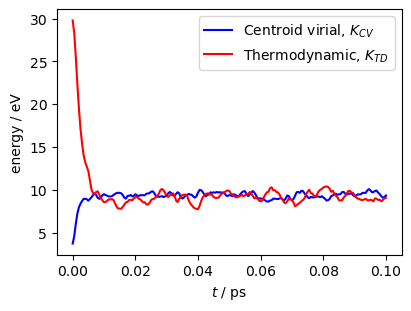

In [13]:
fix, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
ax.plot(
    output_data["time"],
    output_data["kinetic_cv"],
    "b-",
    label="Centroid virial, $K_{CV}$",
)
ax.plot(
    output_data["time"],
    output_data["kinetic_td"],
    "r-",
    label="Thermodynamic, $K_{TD}$",
)
ax.set_xlabel(r"$t$ / ps")
ax.set_ylabel(r"energy / eV")
ax.legend()
plt.show()

In [16]:
traj_pimd = chemiscope.ase_merge_pi_frames(traj_data)
# we also tweak the visualization options, and then show the viewer
traj_pimd["shapes"]["paths"]["parameters"]["global"]["radius"] = 0.05
traj_pimd["settings"]["structure"][0].update(
    dict(
        atoms=False,
        keepOrientation=True,
        color={"property": "bead_id", "palette": "hsv (periodic)"},
    )
)

chemiscope.show(**traj_pimd, mode="structure")

<StructureWidget(meta={'name': ' '}, settings={'structure': [{'atoms': False, 'bonds': False, 'shape': 'paths'…